In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\NANCY\Documents\Solavisetech-women-in-data-cohort2\data.csv\data.csv", encoding='latin1')
print(df)

       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  CustomerID         Country  
0        1

In [2]:
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


### Q1. How many rows and columns does the dataset have?

In [18]:
rows, columns = df.shape
print(f"The dataset has {rows} rows and {columns} columns.")

The dataset has 541909 rows and 8 columns.


### Q2. List all the column names. Which columns do you think will be most useful for analysis and why?

In [7]:
print(df.columns)
print(df.info())

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
None


The dataset has 8 columns: InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID and Country. The most useful columns for business analysis are Description (what was sold), Quantity (how much), UnitPrice (at what price), InvoiceDate (when), CustomerID (who) and Country (where). StockCode is less useful for analysis since Description already tells us what the product is, though it may be useful for inventory tracking purposes.

### Q3. What does one row in this dataset represent? (What is one record?)
One row represents an item purchased by a customer in a single order.

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


### Q4. Which columns contain numbers, and which ones contain text or categories?
Quantity, UnitPrice and CustomerID contain numbers. The remaining columns InvoiceNo, StockCode, Description, InvoiceDate and Country contain text or categories. 

In [14]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


### Q5. How many missing values are there in each column? Which column has the most missing values?
Only two columns have missing values. Description has 1,454 missing values and CustomerID has 135,080 missing values. CustomerID has the most missing values.

### Q6. How did you decide to handle the missing values — did you drop the rows, fill them in, or leave them? Explain your decision.
Missing CustomerID values will be left as NaN rather than filled or dropped. While we cannot identify who placed these orders, the remaining information such as product, quantity, price and country is still valuable for sales and revenue analysis. When analysing customer behaviour specifically, these rows will be excluded.
Rows with missing Description values will be dropped since without knowing what product was sold, those rows have limited analytical value. At only 1,454 rows out of 541,909 the impact on the dataset is minimal.

In [20]:
# Drop rows where Description is missing
df = df.dropna(subset=["Description"])

# Confirm
print(df.shape)
print(df.isnull().sum())

(540455, 8)
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64


### Q7. Did you find any duplicate rows? How many, and what did you do with them?
5,268 duplicate rows were found and were dropped.

In [21]:
print(df.duplicated().sum())

5268


In [22]:
df = df.drop_duplicates()
print(df.shape)

(535187, 8)


### Q8. Are there any column names that are hard to read or have spaces? How did you clean them?
The column names are already clean with no spaces or special characters. However to follow Python's snake_case convention, all column names were converted to lowercase for consistency.

In [23]:
df.columns = ['invoice_no', 'stock_code', 'description', 'quantity', 
              'invoice_date', 'unit_price', 'customer_id', 'country']
print(df.columns)

Index(['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date',
       'unit_price', 'customer_id', 'country'],
      dtype='str')


In [24]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
Index: 535187 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   invoice_no    535187 non-null  str    
 1   stock_code    535187 non-null  str    
 2   description   535187 non-null  str    
 3   quantity      535187 non-null  int64  
 4   invoice_date  535187 non-null  str    
 5   unit_price    535187 non-null  float64
 6   customer_id   401604 non-null  float64
 7   country       535187 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 36.7 MB


invoice_no           0
stock_code           0
description          0
quantity             0
invoice_date         0
unit_price           0
customer_id     133583
country              0
dtype: int64

### Q9. Which country placed the most orders? What percentage of total orders does that country represent?
United Kingdom placed the most orders with 488,846 orders, representing 91.3% of all orders in the dataset.

In [26]:
country_orders = df["country"].value_counts()
print(country_orders.head(10))

country
United Kingdom    488846
Germany             9480
France              8541
EIRE                8184
Spain               2528
Netherlands         2371
Belgium             2069
Switzerland         1994
Portugal            1510
Australia           1258
Name: count, dtype: int64


In [27]:
uk_orders = country_orders["United Kingdom"]
total_orders = len(df)
percentage = (uk_orders / total_orders) * 100
print(f"United Kingdom accounts for {percentage:.1f}% of total orders")

United Kingdom accounts for 91.3% of total orders


### Q10. What are the top 5 best-selling products? How did you decide what 'best-selling' means — by number of orders or by total quantity sold?
Best selling was defined by total quantity sold rather than number of orders, since high order quantities suggest bulk purchasing behaviour in this dataset. 
The top 5 products are: World War 2 Gliders Asstd Designs (53,751 units), Jumbo Bag Red Retrospot (47,260 units), Popcorn Holder (36,322 units), Assorted Colour Bird Ornament (36,282 units) and Pack of 72 Retrospot Cake Cases (36,016 units).

In [28]:
top_products = df.groupby("description")["quantity"].sum().sort_values(ascending=False).head(5)
print(top_products)

description
WORLD WAR 2 GLIDERS ASSTD DESIGNS    53751
JUMBO BAG RED RETROSPOT              47260
POPCORN HOLDER                       36322
ASSORTED COLOUR BIRD ORNAMENT        36282
PACK OF 72 RETROSPOT CAKE CASES      36016
Name: quantity, dtype: int64


### Q11. Which month had the highest total sales revenue? Which month had the lowest?
Month 11 (November) had the highest total revenue at £1,456,145.80, likely driven by early Christmas shopping. Month 4 (April) had the lowest revenue at £492,367.84, reflecting a quieter period between the holiday and summer seasons.

In [29]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"])
print(df["invoice_date"].head())

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: invoice_date, dtype: datetime64[us]


In [30]:
df["month"] = df["invoice_date"].dt.month
df["revenue"] = df["quantity"] * df["unit_price"]
print(df[["invoice_date", "month", "revenue"]].head())

         invoice_date  month  revenue
0 2010-12-01 08:26:00     12    15.30
1 2010-12-01 08:26:00     12    20.34
2 2010-12-01 08:26:00     12    22.00
3 2010-12-01 08:26:00     12    20.34
4 2010-12-01 08:26:00     12    20.34


In [33]:
monthly_revenue = df.groupby("month")["revenue"].sum()
print(f"Highest revenue month: Month {monthly_revenue.idxmax()} with £{monthly_revenue.max():,.2f}")
print(f"Lowest revenue month: Month {monthly_revenue.idxmin()} with £{monthly_revenue.min():,.2f}")

Highest revenue month: Month 11 with £1,456,145.80
Lowest revenue month: Month 4 with £492,367.84


### Q12. What is the average order value (the average amount spent per order)? What is the highest single order value in the dataset?
The average order value is £397.86, meaning customers typically spend around £398 per transaction. The highest single order value was £168,469.60, suggesting the dataset includes large wholesale bulk orders alongside smaller purchases.

In [35]:
order_values = df.groupby("invoice_no")["revenue"].sum()
print(f"Average order value: £{order_values.mean():,.2f}")
print(f"Highest single order value: £{order_values.max():,.2f}")

Average order value: £397.86
Highest single order value: £168,469.60


### Q13. Are there any products that appear to be returned or cancelled? How can you tell from the data?
The dataset contains 9,251 cancelled or returned orders, identified by negative quantities and invoice numbers beginning with 'C'. The 'C' prefix appears to be a convention for cancelled orders, while negative quantities suggest items being returned to reverse the original transaction. These were removed from the dataset to ensure revenue and sales analysis reflects actual completed transactions only.

In [36]:
print(df[df["quantity"] < 0].head())

    invoice_no stock_code                       description  quantity  \
141    C536379          D                          Discount        -1   
154    C536383     35004C   SET OF 3 COLOURED  FLYING DUCKS        -1   
235    C536391      22556    PLASTERS IN TIN CIRCUS PARADE        -12   
236    C536391      21984  PACK OF 12 PINK PAISLEY TISSUES        -24   
237    C536391      21983  PACK OF 12 BLUE PAISLEY TISSUES        -24   

           invoice_date  unit_price  customer_id         country  month  \
141 2010-12-01 09:41:00       27.50      14527.0  United Kingdom     12   
154 2010-12-01 09:49:00        4.65      15311.0  United Kingdom     12   
235 2010-12-01 10:24:00        1.65      17548.0  United Kingdom     12   
236 2010-12-01 10:24:00        0.29      17548.0  United Kingdom     12   
237 2010-12-01 10:24:00        0.29      17548.0  United Kingdom     12   

     revenue  
141   -27.50  
154    -4.65  
235   -19.80  
236    -6.96  
237    -6.96  


In [37]:
cancelled = df[df["invoice_no"].str.startswith("C")]
print(f"Number of cancelled/returned orders: {len(cancelled)}")

Number of cancelled/returned orders: 9251


In [38]:
#removing returned and cancelled products
df = df[df["quantity"] > 0]
df = df[~df["invoice_no"].str.startswith("C")]
print(df.shape)

(525462, 10)


In [39]:
print(df.shape)
print(df.isnull().sum())

(525462, 10)
invoice_no           0
stock_code           0
description          0
quantity             0
invoice_date         0
unit_price           0
customer_id     132730
country              0
month                0
revenue              0
dtype: int64


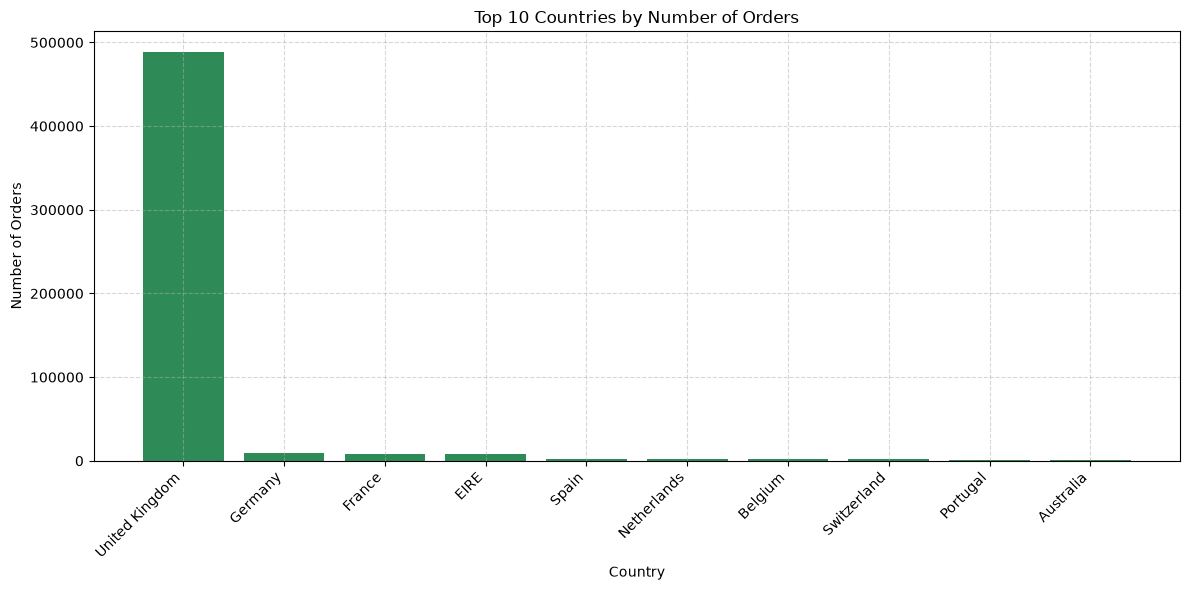

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

top_10_countries = country_orders.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_10_countries.index, top_10_countries.values, color="seagreen")
plt.title("Top 10 Countries by Number of Orders")
plt.xlabel("Country")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### After creating the chart, answer this: What does this chart tell you about where this business gets most of its customers?

This chart confirms that the business is heavily concentrated in the United Kingdom, which dominates orders by a significant margin compared to all other countries combined. If the business is UK based, this domestic dominance is expected and healthy. Germany, France and EIRE are the next largest markets but are far behind. The business could explore targeted marketing campaigns in these countries to grow its international customer base and reduce dependence on a single market.

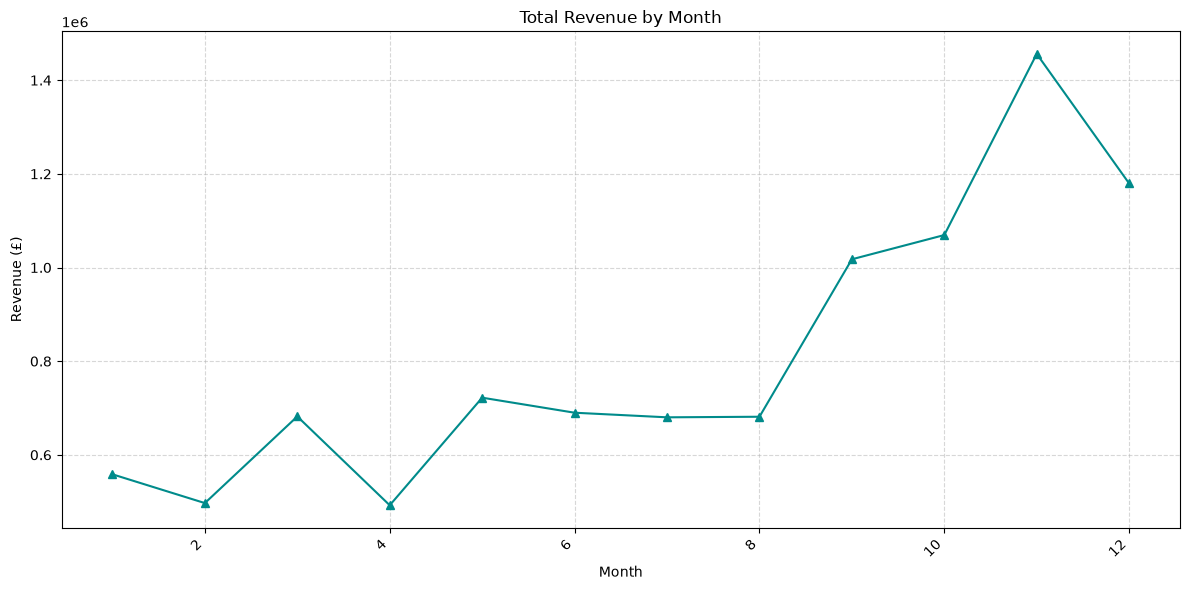

In [50]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, color="darkcyan", marker = "^")
plt.title("Total Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### After creating the chart, answer this: Is there a clear trend or seasonal pattern? When does the business seem busiest?
The line chart reveals a clear seasonal pattern. Revenue remains relatively flat from January to August, suggesting a quieter trading period where customers are not spending heavily. From September onwards revenue rises sharply, peaking in November at £1,456,145.80 before dipping slightly in December. This pattern strongly suggests Christmas driven demand, where customers begin purchasing gifts and homeware from September and the business experiences its busiest trading period in the final quarter of the year. January records the lowest revenue, consistent with post-holiday spending fatigue.

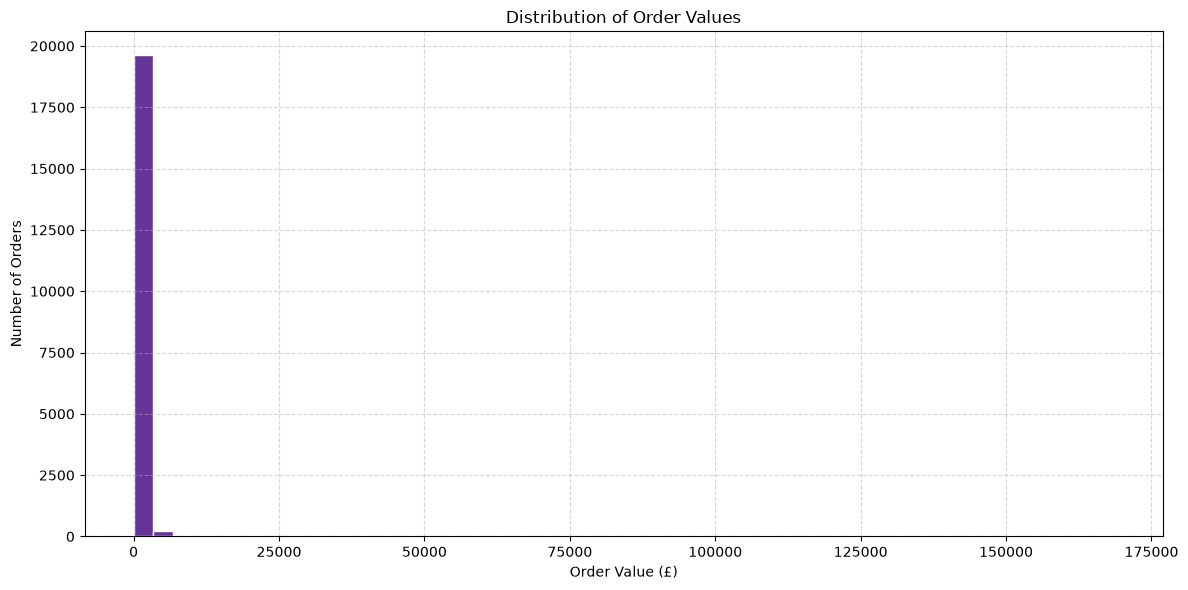

In [52]:
order_values = df.groupby("invoice_no")["revenue"].sum()
order_values = order_values[order_values > 0]

plt.figure(figsize=(12, 6))
plt.hist(order_values.values, bins=50, color="rebeccapurple", edgecolor="white")
plt.title("Distribution of Order Values")
plt.xlabel("Order Value (£)")
plt.ylabel("Number of Orders")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Most orders are small but a few are enormous

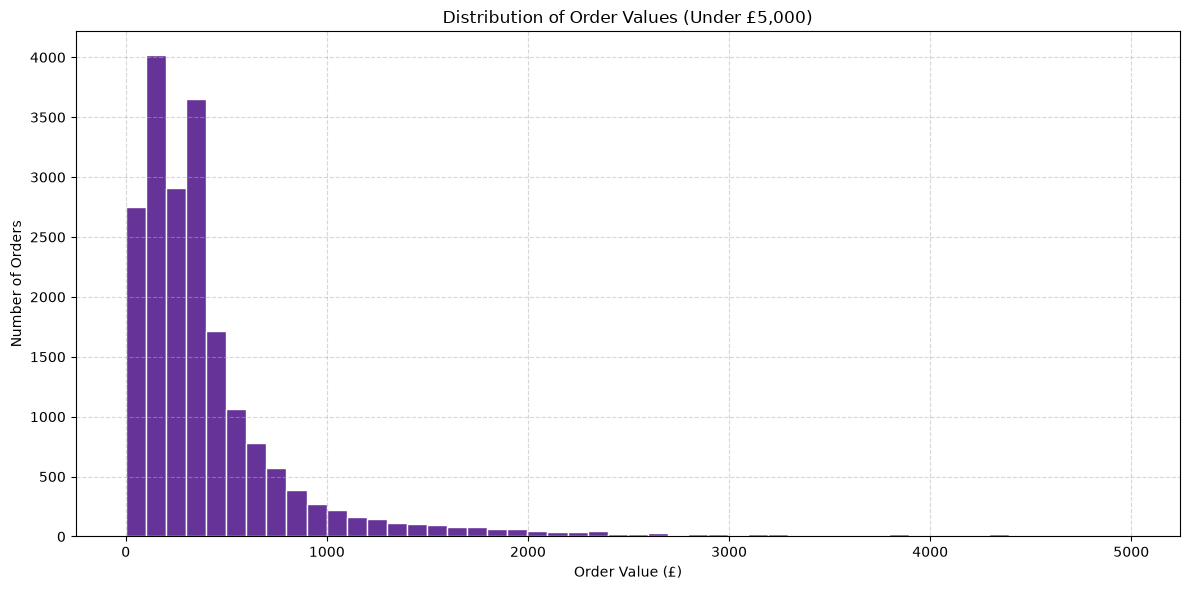

In [53]:
plt.figure(figsize=(12, 6))
plt.hist(order_values[order_values < 5000].values, bins=50, color="rebeccapurple", edgecolor="white")
plt.title("Distribution of Order Values (Under £5,000)")
plt.xlabel("Order Value (£)")
plt.ylabel("Number of Orders")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### After creating the chart, answer this: Are most orders small or large? Is the distribution skewed?
What does that tell you about the typical customer?
The histogram reveals that the vast majority of orders are under £500, with the distribution heavily skewed to the right. This suggests that most customers place relatively small orders while a few place extremely large ones. 

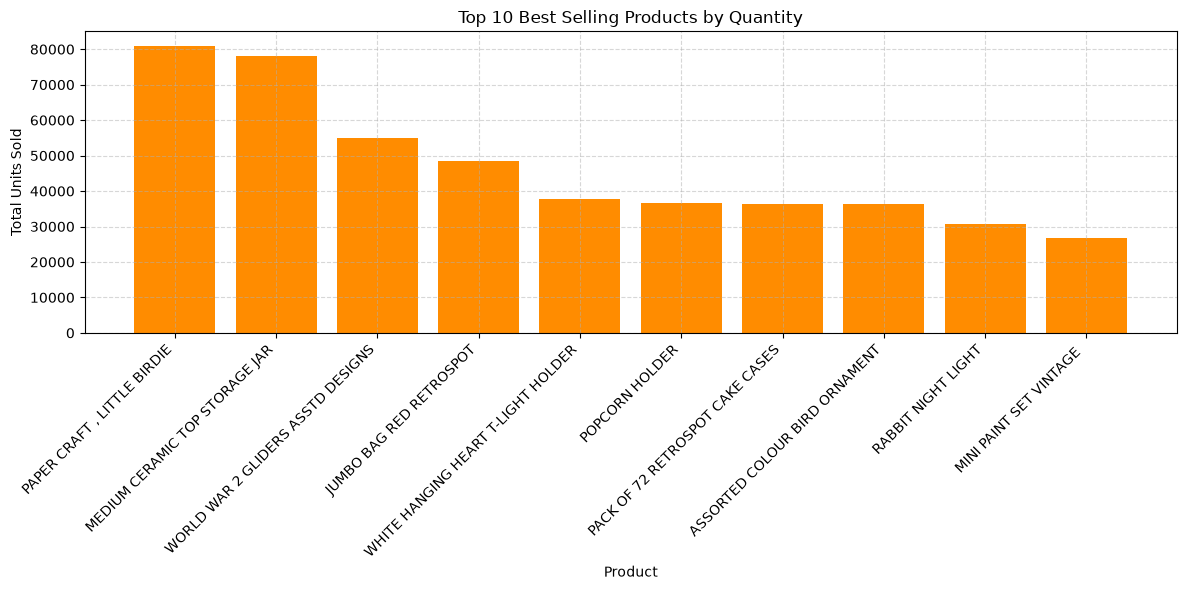

In [54]:
top_products = df.groupby("description")["quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_products.index, top_products.values, color="darkorange")
plt.title("Top 10 Best Selling Products by Quantity")
plt.xlabel("Product")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### After creating the chart, answer this: Which group is most important to this business?
The top 10 best selling products are dominated by novelty, craft and homeware items such as Paper Craft Little Birdie, Medium Ceramic Top Storage Jar and World War 2 Gliders. This tells us the business serves customers who are interested in gifts, home decoration and craft activities. The top two products sold over 75,000 units each, significantly ahead of the rest, suggesting these are the core products driving volume. The business should ensure these items are always well stocked and consider expanding its range in the novelty and homeware category.

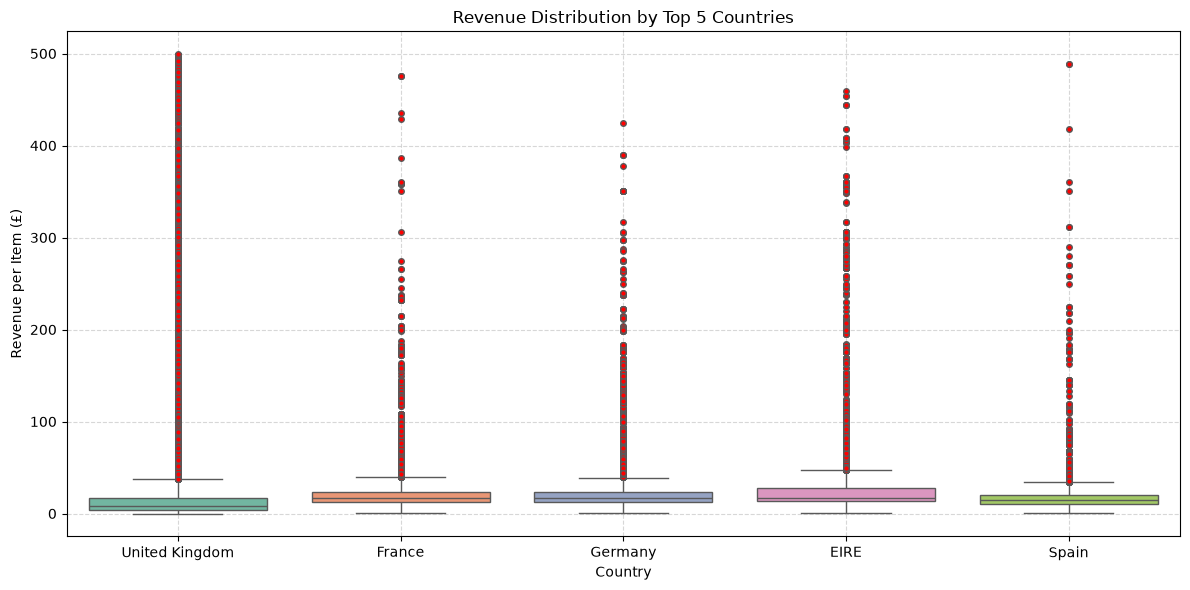

In [58]:
top_5_countries = ["United Kingdom", "Germany", "France", "EIRE", "Spain"]
df_top5 = df[df["country"].isin(top_5_countries) & (df["revenue"] > 0) & (df["revenue"] < 500)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top5, x="country", y="revenue",
            hue="country", palette="Set2", legend=False,
            flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 4})
plt.title("Revenue Distribution by Top 5 Countries")
plt.xlabel("Country")
plt.ylabel("Revenue per Item (£)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### After creating the chart, answer this: Why did you choose this chart? What question were you trying to answer?
This box plot compares spending patterns across the top 5 countries. All five countries show boxes sitting close to zero, meaning most purchases are small regardless of location. However EIRE stands out with the most visible outlier dots relative to its box size, suggesting its customers are more likely to place high value orders compared to other markets. This makes EIRE a potentially valuable market to invest in despite its smaller order volume.
I chose a box plot because I wanted to understand not just how much each country orders, but how consistent their spending is. A bar chart would only show totals while a box plot reveals the spread, the typical transaction size and the presence of unusual high value purchases. The question I was trying to answer was: do customers spend similarly across different countries or are there markets where spending is more varied and potentially more valuable?

## INSIGHTS
Insight 1:
The United Kingdom placed 488,846 orders, accounting for 91.3% of all transactions. Every other country combined represents less than 9% of the business, indicating extreme market concentration.


Insight 2:
November generated £1,456,145.80 in revenue, nearly 3x more than April's £492,367.84, suggesting a strong Christmas driven seasonal peak in the final quarter of the year.


Insight 3:
Paper Craft Little Birdie and Medium Ceramic Top Storage Jar are the top selling products with over 75,000 units each, significantly ahead of all other products, confirming novelty and homeware as the core product categories.


Insight 4:
The majority of orders fall under £500, yet the highest single order reached £168,469.60, creating a heavily right skewed distribution where the average order value of £397.86 overstates what a typical customer actually spends.


Insight 5:
EIRE placed far fewer orders than UK but shows a higher concentration of high value transactions, suggesting it contains premium customers who spend more per order than the typical UK buyer.

### Q14. Looking at your top countries by orders — should the business focus more resources on its biggest market, or try to grow in the smaller markets? What does your data suggest?
The business should maintain its UK focus since it provides stable and reliable volume. However, relying on one market for 91.3% of revenue is a risk. Any economic downturn or disruption in the UK could seriously impact the whole business. Markets like EIRE, Netherlands and Australia show strong high value purchasing behaviour despite low order volumes, suggesting untapped potential. Targeted marketing campaigns in these countries could grow international revenue without reducing UK performance.

### Q15. Based on your monthly sales trend, when should the business run its biggest promotions? When should it prepare its stock and staffing levels?
Based on the monthly sales trend, the business should run its biggest promotions from September onwards, as this is when revenue begins climbing toward the November peak. Running promotions earlier in September and October would help capture customers before the Christmas rush and maximise the seasonal window.
Stock and staffing preparation should happen during the quieter months of April through August, when there is time and capacity to build inventory without the pressure of high demand. Additional temporary staff should be brought on from September to handle the surge, with peak staffing in November when revenue is at its highest. January and February are ideal for reviewing stock levels, clearing excess inventory and planning for the next seasonal cycle.

In [61]:
worst_products = df.groupby("description")["quantity"].sum().sort_values(ascending=True).head(10)
print(worst_products)

description
RUBY GLASS NECKLACE 42"            1
LILY BROOCH WHITE/SILVER COLOUR    1
FIRE POLISHED GLASS NECKL GOLD     1
WIRE FLOWER T-LIGHT HOLDER         1
JARDIN ETCHED GLASS BUTTER DISH    1
DUSTY PINK CHRISTMAS TREE 30CM     1
TINY CRYSTAL BRACELET RED          1
DOLPHIN WINDMILL                   1
PINK CRYSTAL GUITAR PHONE CHARM    1
HAYNES CAMPER SHOULDER BAG         1
Name: quantity, dtype: int64


### Q16. Looking at the best-selling and worst-selling products — what would you recommend the business does with the products at the bottom of the list?
The worst selling products each sold only 1 unit, suggesting they have little to no market demand. The business has two options. First, it could discontinue these products entirely and reinvest the storage space and budget into top performing lines like Paper Craft Little Birdie and Medium Ceramic Top Storage Jar, which would directly boost revenue. Second, before discontinuing, the business should investigate why these products are underperforming. It could be poor visibility on the website, wrong pricing or simply the wrong audience. A small targeted campaign aimed at the right demographic could turn some of these products around before writing them off completely.

### Q17. If the business asked you: 'What one thing should we do differently to increase revenue?' — what would you say, and what data supports that answer?
The single most impactful thing the business could do to increase revenue is run targeted promotions during its slow months, particularly from January through August. The data shows November generates nearly 3x more revenue than April, meaning the business is heavily dependent on a short Christmas driven peak. This creates risk and leaves significant revenue on the table during quieter periods. Promotions such as seasonal discounts, bundle deals and early Christmas ordering incentives during the slow months would encourage customers to spread their purchases across the year rather than concentrating them in November. This would not only increase annual revenue but also reduce the operational pressure of handling a massive spike in a single month.

### FINAL RECOMMENDATIONS
Recommendation 1:
Focus on seasonal promotions during slow months (January through August) to reduce the revenue gap between peak and off-peak periods. The data shows November generates nearly 3x more than April, leaving significant revenue uncaptured during quieter months.

Recommendation 2:
Invest in growing international markets like EIRE, Netherlands and Australia, where customers show higher value purchasing behaviour despite low order volumes. Targeted marketing campaigns in these countries could diversify revenue away from the UK's 91.3% dominance and reduce business risk.

Recommendation 3:
Discontinue or investigate the worst selling products that have sold only 1 unit each, and reinvest that budget and storage space into top performing lines like Paper Craft Little Birdie and Medium Ceramic Top Storage Jar. Focusing resources on proven sellers will directly improve revenue and operational efficiency.

### REFLECTION 
Working through this dataset revealed just how much story is hidden inside raw numbers. The most surprising finding was that the United Kingdom, despite dominating 91.3% of all orders, actually has the lowest rate of high value purchases among the top 5 countries. EIRE and other smaller markets punch well above their weight in terms of spending per transaction, which completely changed how I thought about market value. The hardest part was handling the missing values and cancelled orders, because there was no single right answer and every decision had to be justified with reasoning rather than just code. If I had more time I would investigate what specifically drives the November peak beyond just Christmas shopping, whether there are particular products or customer segments that account for the surge, and whether the slow months could be meaningfully improved through targeted promotions. I would also explore why so many CustomerIDs are missing and whether that points to a data collection problem worth fixing at the source.